In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
df=pd.read_csv("uncleaned_gaming_app_dataset_with_continuous.csv")
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iPhone 11,2.0,NaN,48.93,-3.0,two,Yes,24.0
1,U3926,Samsung-A10,3.0,v1_3,21.86,-3.0,NaN,no,1.0
2,U4125,Redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,Redmi9,4.0,NaN,34.08,10.0,two,yes,-5.0
4,U1113,iPhone 11,3.0,v1_3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,Samsung A10,6.0,1.2.1,35.28,NaN,2,no,1.0
1196,U1302,iPhone 11,2.0,v1_3,55.62,NaN,0,Yes,-5.0
1197,U9899,Samsung-A10,3.0,NaN,41.08,NaN,two,yes,1.0
1198,U8283,iPhone 11,6.0,NaN,30.43,-3.0,two,No,1.0


In [11]:
df.shape

(1200, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1089 non-null   object 
 1   device_model          1002 non-null   object 
 2   ram_gb                981 non-null    float64
 3   update_version        879 non-null    object 
 4   avg_fps               1200 non-null   float64
 5   session_duration_min  1013 non-null   float64
 6   crash_count           986 non-null    object 
 7   uninstalled           959 non-null    object 
 8   uninstall_time_hours  996 non-null    float64
dtypes: float64(4), object(5)
memory usage: 84.5+ KB


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["user_id"].unique()

array(['U5635', 'U3926', 'U4125', ..., 'U1302', 'U9899', 'U8283'],
      dtype=object)

In [15]:
df["user_id"].nunique()

1036

In [16]:
df["device_model"].unique()

array(['iPhone 11', 'Samsung-A10', 'Redmi9', 'Samsung A10', 'Redmi 9',
       nan], dtype=object)

In [17]:
df["device_model"].value_counts()

device_model
Samsung A10    219
iPhone 11      203
Samsung-A10    199
Redmi9         191
Redmi 9        190
Name: count, dtype: int64

In [18]:
df['ram_gb'].value_counts()

ram_gb
3.0    258
2.0    257
4.0    241
6.0    225
Name: count, dtype: int64

In [19]:
df['update_version'].unique()

array([nan, 'v1_3', 'v1.2', '1.2.1'], dtype=object)

In [20]:
df['update_version'].nunique()

3

In [21]:
df['avg_fps'].nunique()

1054

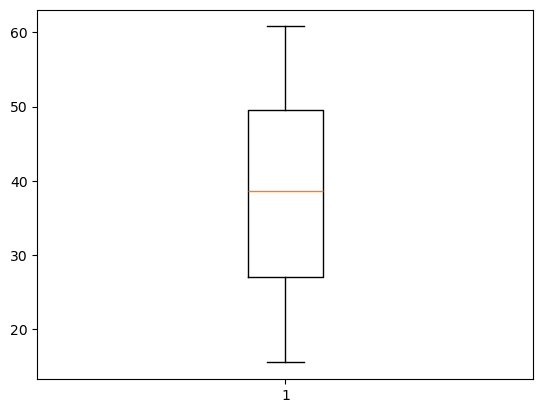

In [22]:
plt.boxplot(df["avg_fps"])
plt.show()

In [23]:
df['session_duration_min'].value_counts()

session_duration_min
 5.0     212
-3.0     207
 10.0    205
 15.0    200
 20.0    189
Name: count, dtype: int64

In [24]:
df['crash_count'].nunique()

4

In [25]:
df['crash_count'].value_counts()

crash_count
1      253
0      248
2      245
two    240
Name: count, dtype: int64

In [26]:
df['uninstalled'].nunique()

4

In [27]:
df['uninstalled'].value_counts()

uninstalled
No     247
no     244
yes    242
Yes    226
Name: count, dtype: int64

In [28]:
df['uninstall_time_hours'].nunique()

5

In [29]:
df['uninstall_time_hours'].value_counts()

uninstall_time_hours
 12.0    219
 24.0    205
 1.0     204
-5.0     188
 6.0     180
Name: count, dtype: int64

In [30]:
df.dtypes

user_id                  object
device_model             object
ram_gb                  float64
update_version           object
avg_fps                 float64
session_duration_min    float64
crash_count              object
uninstalled              object
uninstall_time_hours    float64
dtype: object

In [31]:
category=["user_id","device_model","update_version"]
df[category]=df[category].astype('category')
category

['user_id', 'device_model', 'update_version']

In [32]:
# Convert to string (removes categorical restriction)
df["user_id"] = df["user_id"].astype(str)
# Replace NaN (if any appear as 'nan') with "unknown"
df["user_id"].replace("nan", "unknown", inplace=True)


In [33]:
category=["user_id","device_model","update_version"]
df[category]=df[category].astype('category')
category

['user_id', 'device_model', 'update_version']

In [34]:
df['device_model']=df['device_model'].str.strip().str.lower()
df['device_model']=df['device_model'].replace({'Samsung-A10':'samsung-a10','Redmi 9':'redmi 9'})


In [35]:
df.loc[df["device_model"]=="samsung a10","device_model"]="samsung-a10"
for col in ["device_model"]:
    df[col].fillna(df[col].mode()[0],inplace=True)
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,NaN,48.93,-3.0,two,Yes,24.0
1,U3926,samsung-a10,3.0,v1_3,21.86,-3.0,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,redmi9,4.0,NaN,34.08,10.0,two,yes,-5.0
4,U1113,iphone 11,3.0,v1_3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,NaN,2,no,1.0
1196,U1302,iphone 11,2.0,v1_3,55.62,NaN,0,Yes,-5.0
1197,U9899,samsung-a10,3.0,NaN,41.08,NaN,two,yes,1.0
1198,U8283,iphone 11,6.0,NaN,30.43,-3.0,two,No,1.0


In [36]:
category=["user_id","device_model","update_version"]
df[category]=df[category].astype('category')
category

['user_id', 'device_model', 'update_version']

In [37]:
df["ram_gb"] = df["ram_gb"].round(0)

In [38]:
df["ram_gb"].fillna(df["ram_gb"].median(), inplace=True)
df


,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,NaN,48.93,-3.0,two,Yes,24.0
1,U3926,samsung-a10,3.0,v1_3,21.86,-3.0,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,redmi9,4.0,NaN,34.08,10.0,two,yes,-5.0
4,U1113,iphone 11,3.0,v1_3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,NaN,2,no,1.0
1196,U1302,iphone 11,2.0,v1_3,55.62,NaN,0,Yes,-5.0
1197,U9899,samsung-a10,3.0,NaN,41.08,NaN,two,yes,1.0
1198,U8283,iphone 11,6.0,NaN,30.43,-3.0,two,No,1.0


In [39]:
df["update_version"] = df["update_version"].str.replace("_", ".", regex=False)
for col in ["update_version"]:
    df[col].fillna("unknown",inplace=True)
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,unknown,48.93,-3.0,two,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,-3.0,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,redmi9,4.0,unknown,34.08,10.0,two,yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,NaN,2,no,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,NaN,0,Yes,-5.0
1197,U9899,samsung-a10,3.0,unknown,41.08,NaN,two,yes,1.0
1198,U8283,iphone 11,6.0,unknown,30.43,-3.0,two,No,1.0


In [40]:
df["update_version"]=df["update_version"].replace(["Unknown","unknown"],np.nan)
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,NaN,48.93,-3.0,two,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,-3.0,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,redmi9,4.0,NaN,34.08,10.0,two,yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,NaN,2,no,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,NaN,0,Yes,-5.0
1197,U9899,samsung-a10,3.0,NaN,41.08,NaN,two,yes,1.0
1198,U8283,iphone 11,6.0,NaN,30.43,-3.0,two,No,1.0


In [41]:
mode_value = df['update_version'].mode()[0]  # find mode
df['update_version'].fillna(mode_value, inplace=True)
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,1.2.1,48.93,-3.0,two,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,-3.0,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,redmi9,4.0,1.2.1,34.08,10.0,two,yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,NaN,2,no,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,NaN,0,Yes,-5.0
1197,U9899,samsung-a10,3.0,1.2.1,41.08,NaN,two,yes,1.0
1198,U8283,iphone 11,6.0,1.2.1,30.43,-3.0,two,No,1.0


In [42]:
df.loc[df['session_duration_min'] < 0, 'session_duration_min'] = np.nan
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,1.2.1,48.93,NaN,two,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,NaN,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,redmi9,4.0,1.2.1,34.08,10.0,two,yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,NaN,2,no,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,NaN,0,Yes,-5.0
1197,U9899,samsung-a10,3.0,1.2.1,41.08,NaN,two,yes,1.0
1198,U8283,iphone 11,6.0,1.2.1,30.43,NaN,two,No,1.0


In [43]:
df["session_duration_min"].fillna(df["session_duration_min"].mean(),inplace=True)
df["session_duration_min"]=df["session_duration_min"].round(1)
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,1.2.1,48.93,12.3,two,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,12.3,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2,yes,-5.0
3,U4636,redmi9,4.0,1.2.1,34.08,10.0,two,yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,12.3,2,no,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,12.3,0,Yes,-5.0
1197,U9899,samsung-a10,3.0,1.2.1,41.08,12.3,two,yes,1.0
1198,U8283,iphone 11,6.0,1.2.1,30.43,12.3,two,No,1.0


In [44]:
df["crash_count"] = df["crash_count"].replace("two", 2)
df["crash_count"] = pd.to_numeric(df["crash_count"], errors="coerce")
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,1.2.1,48.93,12.3,2.0,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,12.3,NaN,no,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2.0,yes,-5.0
3,U4636,redmi9,4.0,1.2.1,34.08,10.0,2.0,yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,NaN,no,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,12.3,2.0,no,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,12.3,0.0,Yes,-5.0
1197,U9899,samsung-a10,3.0,1.2.1,41.08,12.3,2.0,yes,1.0
1198,U8283,iphone 11,6.0,1.2.1,30.43,12.3,2.0,No,1.0


In [45]:
df["crash_count"].fillna(df["crash_count"].median(), inplace=True)


<Axes: >

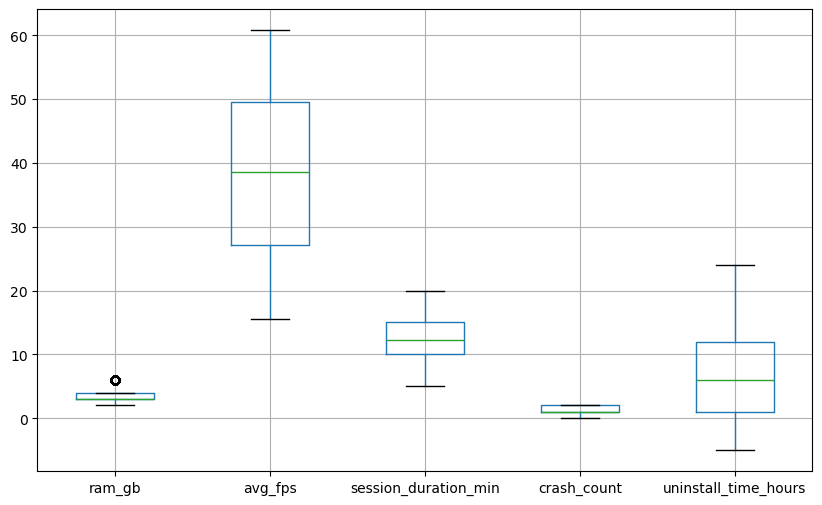

In [46]:
df.select_dtypes(include='number').boxplot(figsize=(10,6))

In [47]:
df["uninstalled"]=df["uninstalled"].replace("yes","Yes")
df["uninstalled"]=df["uninstalled"].replace("no","No")
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,1.2.1,48.93,12.3,2.0,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,12.3,1.0,No,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2.0,Yes,-5.0
3,U4636,redmi9,4.0,1.2.1,34.08,10.0,2.0,Yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,1.0,No,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,12.3,2.0,No,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,12.3,0.0,Yes,-5.0
1197,U9899,samsung-a10,3.0,1.2.1,41.08,12.3,2.0,Yes,1.0
1198,U8283,iphone 11,6.0,1.2.1,30.43,12.3,2.0,No,1.0


In [48]:
mode_value = df['uninstalled'].mode()[0]  # find mode
df['uninstalled'].fillna(mode_value, inplace=True)
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,1.2.1,48.93,12.3,2.0,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,12.3,1.0,No,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2.0,Yes,-5.0
3,U4636,redmi9,4.0,1.2.1,34.08,10.0,2.0,Yes,-5.0
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,1.0,No,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,12.3,2.0,No,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,12.3,0.0,Yes,-5.0
1197,U9899,samsung-a10,3.0,1.2.1,41.08,12.3,2.0,Yes,1.0
1198,U8283,iphone 11,6.0,1.2.1,30.43,12.3,2.0,No,1.0


In [49]:
df.loc[df["uninstall_time_hours"]<0,"uninstall_time_hours"]=np.nan
df

,user_id,device_model,ram_gb,update_version,avg_fps,session_duration_min,crash_count,uninstalled,uninstall_time_hours
0,U5635,iphone 11,2.0,1.2.1,48.93,12.3,2.0,Yes,24.0
1,U3926,samsung-a10,3.0,v1.3,21.86,12.3,1.0,No,1.0
2,U4125,redmi9,3.0,v1.2,20.35,20.0,2.0,Yes,NaN
3,U4636,redmi9,4.0,1.2.1,34.08,10.0,2.0,Yes,NaN
4,U1113,iphone 11,3.0,v1.3,33.34,10.0,1.0,No,24.0
...,...,...,...,...,...,...,...,...,...
1195,U4353,samsung-a10,6.0,1.2.1,35.28,12.3,2.0,No,1.0
1196,U1302,iphone 11,2.0,v1.3,55.62,12.3,0.0,Yes,NaN
1197,U9899,samsung-a10,3.0,1.2.1,41.08,12.3,2.0,Yes,1.0
1198,U8283,iphone 11,6.0,1.2.1,30.43,12.3,2.0,No,1.0


In [50]:
df["uninstall_time_hours"] = df["uninstall_time_hours"].clip(lower=0)


In [51]:
df.isnull().sum()


user_id                   0
device_model              0
ram_gb                    0
update_version            0
avg_fps                   0
session_duration_min      0
crash_count               0
uninstalled               0
uninstall_time_hours    392
dtype: int64

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   user_id               1200 non-null   category
 1   device_model          1200 non-null   category
 2   ram_gb                1200 non-null   float64 
 3   update_version        1200 non-null   object  
 4   avg_fps               1200 non-null   float64 
 5   session_duration_min  1200 non-null   float64 
 6   crash_count           1200 non-null   float64 
 7   uninstalled           1200 non-null   object  
 8   uninstall_time_hours  808 non-null    float64 
dtypes: category(2), float64(5), object(2)
memory usage: 109.9+ KB


<Axes: >

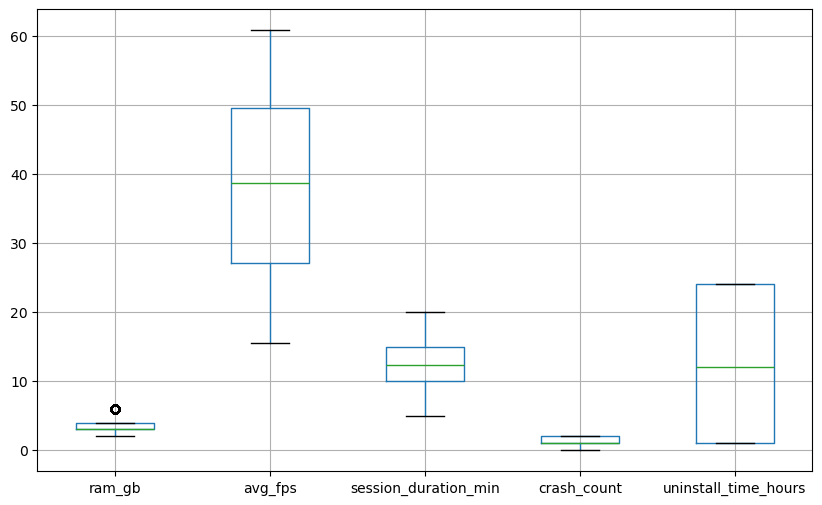

In [53]:
df.select_dtypes(include='number').boxplot(figsize=(10,6))

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   user_id               1200 non-null   category
 1   device_model          1200 non-null   category
 2   ram_gb                1200 non-null   float64 
 3   update_version        1200 non-null   object  
 4   avg_fps               1200 non-null   float64 
 5   session_duration_min  1200 non-null   float64 
 6   crash_count           1200 non-null   float64 
 7   uninstalled           1200 non-null   object  
 8   uninstall_time_hours  808 non-null    float64 
dtypes: category(2), float64(5), object(2)
memory usage: 109.9+ KB


In [55]:
df.select_dtypes(include='number')\
.where(df.select_dtypes(include='number')<0)\
.stack()

Series([], dtype: float64)

In [56]:

df.duplicated().sum()

np.int64(0)

In [57]:
df.isnull().sum()

user_id                   0
device_model              0
ram_gb                    0
update_version            0
avg_fps                   0
session_duration_min      0
crash_count               0
uninstalled               0
uninstall_time_hours    392
dtype: int64

In [58]:
df.info()
    


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   user_id               1200 non-null   category
 1   device_model          1200 non-null   category
 2   ram_gb                1200 non-null   float64 
 3   update_version        1200 non-null   object  
 4   avg_fps               1200 non-null   float64 
 5   session_duration_min  1200 non-null   float64 
 6   crash_count           1200 non-null   float64 
 7   uninstalled           1200 non-null   object  
 8   uninstall_time_hours  808 non-null    float64 
dtypes: category(2), float64(5), object(2)
memory usage: 109.9+ KB


In [59]:
# Save cleaned dataframe to CSV
df.to_csv("cleaned_gaming_app_dataset_final.csv", index=False)


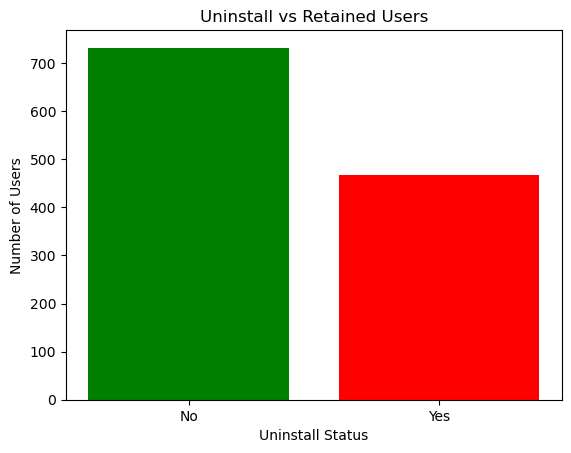

In [63]:
import matplotlib.pyplot as plt
green = "green"
red = "red"
counts = df["uninstalled"].value_counts()
plt.bar(counts.index, counts.values, color=[green, red])
plt.title("Uninstall vs Retained Users")
plt.xlabel("Uninstall Status")
plt.ylabel("Number of Users")
plt.show()



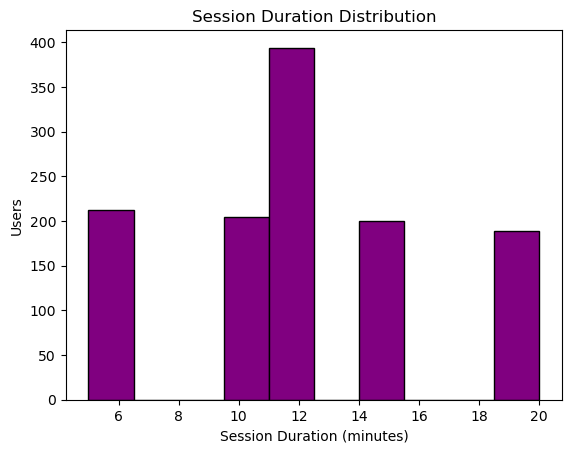

In [64]:
plt.hist(df["session_duration_min"], bins=10, color="purple", edgecolor="black")
plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Users")
plt.show()


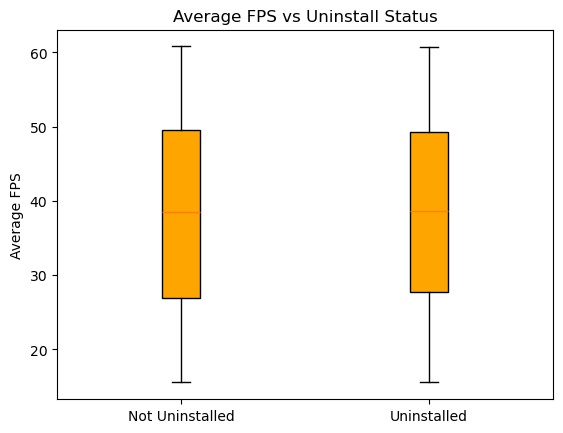

In [68]:
not_uninstalled = df[df["uninstalled"] == "No"]["avg_fps"]
uninstalled = df[df["uninstalled"] == "Yes"]["avg_fps"]

plt.boxplot(
    [not_uninstalled, uninstalled],
    labels=["Not Uninstalled", "Uninstalled"],
    patch_artist=True,
    boxprops=dict(facecolor="orange")
)
plt.title("Average FPS vs Uninstall Status")
plt.ylabel("Average FPS")
plt.show()


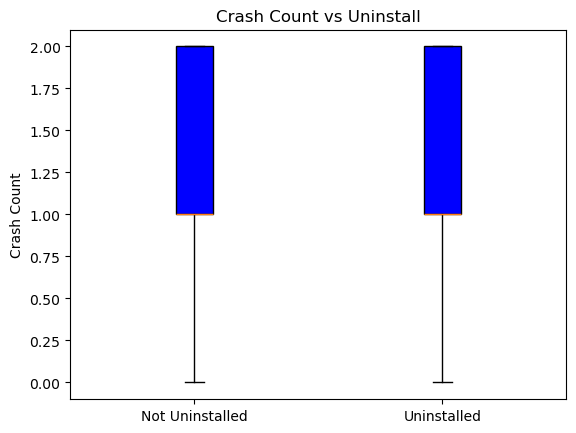

In [70]:
not_uninstalled = df[df["uninstalled"] == "No"]["crash_count"]
uninstalled = df[df["uninstalled"] == "Yes"]["crash_count"]

plt.boxplot(
    [not_uninstalled, uninstalled],
    labels=["Not Uninstalled", "Uninstalled"],
    patch_artist=True,
    boxprops=dict(facecolor="blue")
)
plt.title("Crash Count vs Uninstall")
plt.ylabel("Crash Count")
plt.show()


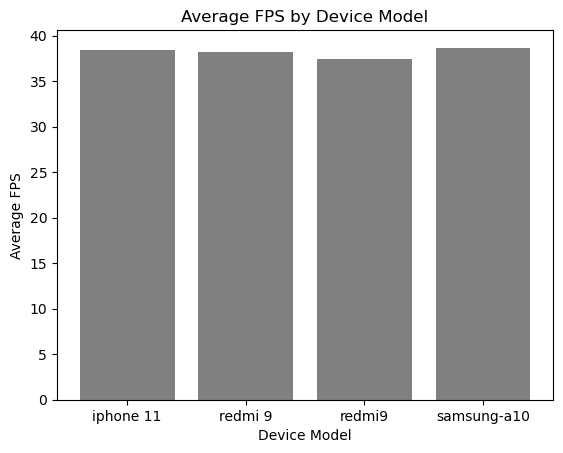

In [71]:
avg_fps_device = df.groupby("device_model")["avg_fps"].mean()
plt.bar(avg_fps_device.index, avg_fps_device.values, color="gray")
plt.title("Average FPS by Device Model")
plt.xlabel("Device Model")
plt.ylabel("Average FPS")
plt.show()


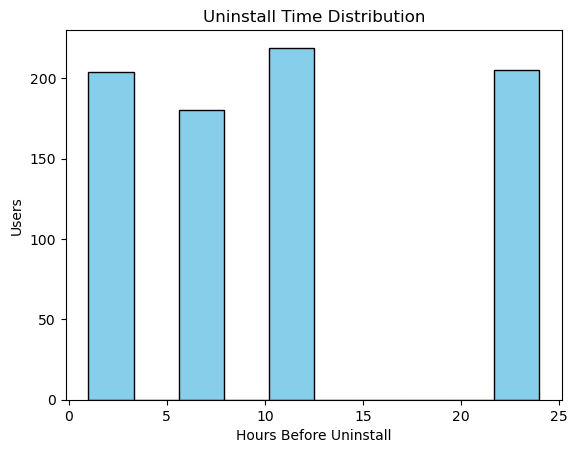

In [76]:
plt.hist(df["uninstall_time_hours"], bins=10, color="Skyblue", edgecolor="black")
plt.title("Uninstall Time Distribution")
plt.xlabel("Hours Before Uninstall")
plt.ylabel("Users")
plt.show()


ValueError: 'facecolor' or 'color' argument must be a valid color orsequence of colors.

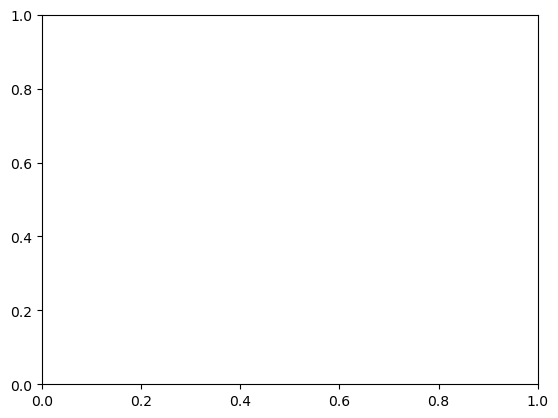

In [78]:
uninstall_rate = df.groupby("update_version")["uninstalled"].apply(lambda x: (x == "Yes").mean())
plt.bar(uninstall_rate.index, uninstall_rate.values, color="darked")
plt.title("Uninstall Rate by App Version")
plt.xlabel("App Version")
plt.ylabel("Uninstall Rate")
plt.show()
